In [7]:
import os
import glob

# Correct path to the class folders
base_dir = "./yelp_photos/balanced_labeled_photos"

# Verify the classes
class_names = os.listdir(base_dir)
print("Classes found:", class_names)

# Count number of images in each class
print("\n Image count per class:")
for class_name in class_names:
    class_path = os.path.join(base_dir, class_name)
    num_images = len(glob.glob(os.path.join(class_path, '*')))
    print(f"{class_name}: {num_images} images")

Classes found: ['drink', 'food', 'inside', 'menu', 'outside']

 Image count per class:
drink: 15670 images
food: 20000 images
inside: 20000 images
menu: 20000 images
outside: 18569 images


## Downsampling the images to 1000

In [12]:
import os
import shutil
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paths
original_dir = "./yelp_photos/balanced_labeled_photos"
balanced_dir = "./yelp_photos/svm_ready_data"
train_dir = os.path.join(balanced_dir, 'train')
test_dir = os.path.join(balanced_dir, 'test')

# Parameters
min_images = 1000
split_ratio = 0.8

# Clean old output dirs
shutil.rmtree(balanced_dir, ignore_errors=True)

# Process each class
for cls in os.listdir(original_dir):
    cls_path = os.path.join(original_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    selected_images = images[:min_images]

    # Split
    split_index = int(split_ratio * min_images)
    train_imgs = selected_images[:split_index]
    test_imgs = selected_images[split_index:]

    # Create output folders
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Copy train images
    for img in tqdm(train_imgs, desc=f"Copying {cls} train"):
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))

    # Copy test images
    for img in tqdm(test_imgs, desc=f"Copying {cls} test"):
        shutil.copy(os.path.join(cls_path, img), os.path.join(test_dir, cls, img))

print("Downsampled and split to 1000 per class successfully.")

Copying outside test: 100%|█████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 279.40it/s]

Downsampled and split to 1000 per class successfully.


## Visualizing to Verify the Downsample

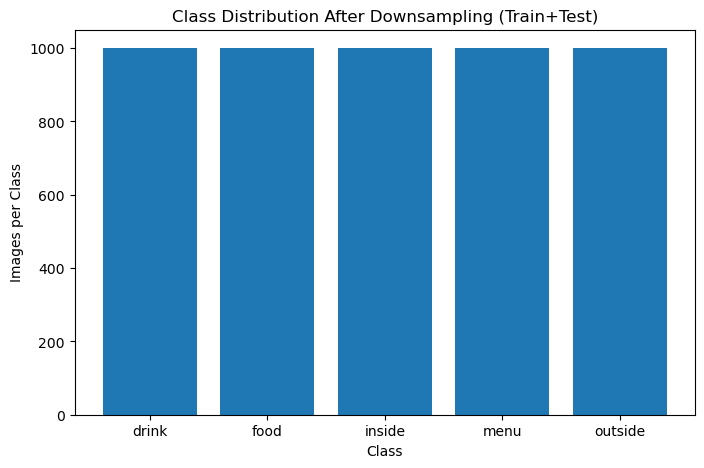

In [15]:
# Visualize new class distribution
plt.figure(figsize=(8,5))
plt.bar(os.listdir(original_dir), [min_images]*5)
plt.title("Class Distribution After Downsampling (Train+Test)")
plt.ylabel("Images per Class")
plt.xlabel("Class")
plt.show()

In [17]:
## Importing necessary libraries
import os
import numpy as np
from sklearn import svm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
## Load Images
def load_dataset(base_path, img_size=(32, 32)):
    X, y = [], []
    class_names = sorted(os.listdir(base_path))

    for label in class_names:
        class_folder = os.path.join(base_path, label)
        for img_file in tqdm(os.listdir(class_folder), desc=f"Loading {label}"):
            try:
                img_path = os.path.join(class_folder, img_file)
                img = load_img(img_path, target_size=img_size)
                img_array = img_to_array(img) / 255.0
                X.append(img_array.flatten())
                y.append(label)
            except Exception as e:
                continue
    return np.array(X), np.array(y)

X_train, y_train = load_dataset("./yelp_photos/svm_ready_data/train")
X_test, y_test = load_dataset("./yelp_photos/svm_ready_data/test")

print(f" Loaded {len(X_train)} training and {len(X_test)} testing samples.")

Loading outside: 100%|██████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 516.02it/s]


 Loaded 4000 training and 1000 testing samples.


In [23]:
## Encode and Scale
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA
### Reducing the features


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=300, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## Train the SVM Model

In [29]:
clf = svm.SVC(kernel='rbf', probability=True)
clf.fit(X_train_scaled, y_train_enc)
print("SVM model trained.")

SVM model trained.


In [31]:
# Predict
y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test_enc, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Full classification report
print("Classification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.6640
Classification Report:
              precision    recall  f1-score   support

       drink       0.57      0.58      0.58       200
        food       0.72      0.71      0.72       200
      inside       0.61      0.75      0.67       200
        menu       0.75      0.60      0.66       200
     outside       0.71      0.68      0.69       200

    accuracy                           0.66      1000
   macro avg       0.67      0.66      0.66      1000
weighted avg       0.67      0.66      0.66      1000



## Confusion Matrix

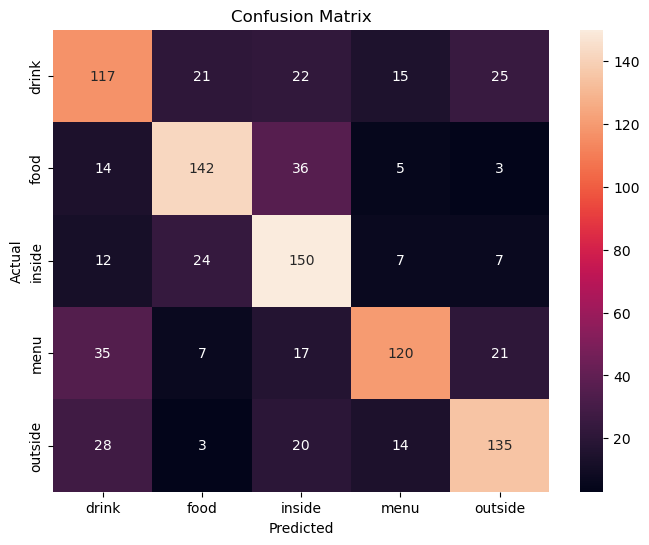

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ROC Curve + AUC Score

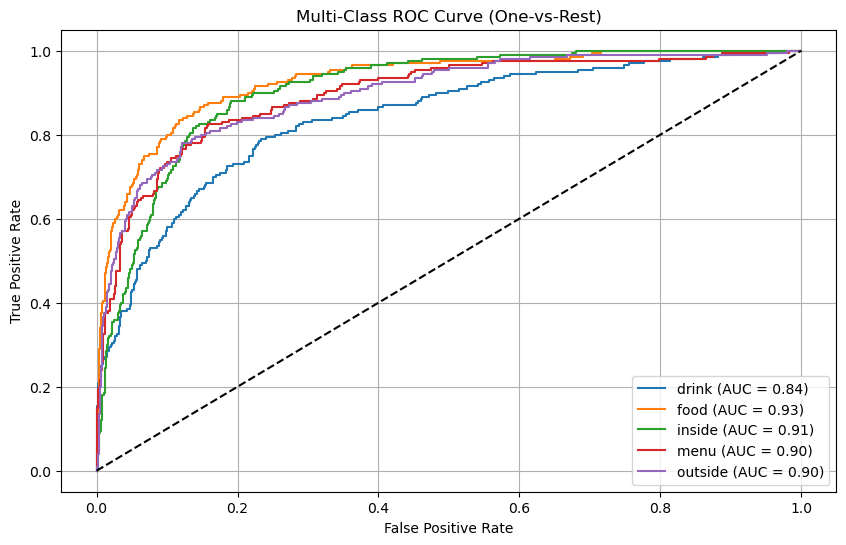

Macro AUC Score: 0.8942


In [39]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize test labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))

# ROC Curve per class
plt.figure(figsize=(10, 6))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Macro AUC Score
auc_macro = roc_auc_score(y_test_enc, y_proba, multi_class='ovr')
print(f"Macro AUC Score: {auc_macro:.4f}")

## Hyperparameter Tuning
### Randomized SearchCV

## PCA

In [43]:
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Apply PCA
pca = PCA(n_components=300, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [45]:
# Fast hyperparameter tuning
param_dist = {
    'C': uniform(0.1, 10),
    'gamma': uniform(0.001, 0.05),
    'kernel': ['rbf']
}

rand_search = RandomizedSearchCV(
    svm.SVC(probability=True),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train_pca, y_train_enc)
best_model = rand_search.best_estimator_
print("Best parameters:", rand_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'C': 1.6601864044243653, 'gamma': 0.008799726016810134, 'kernel': 'rbf'}


## ROC Curve for All Class

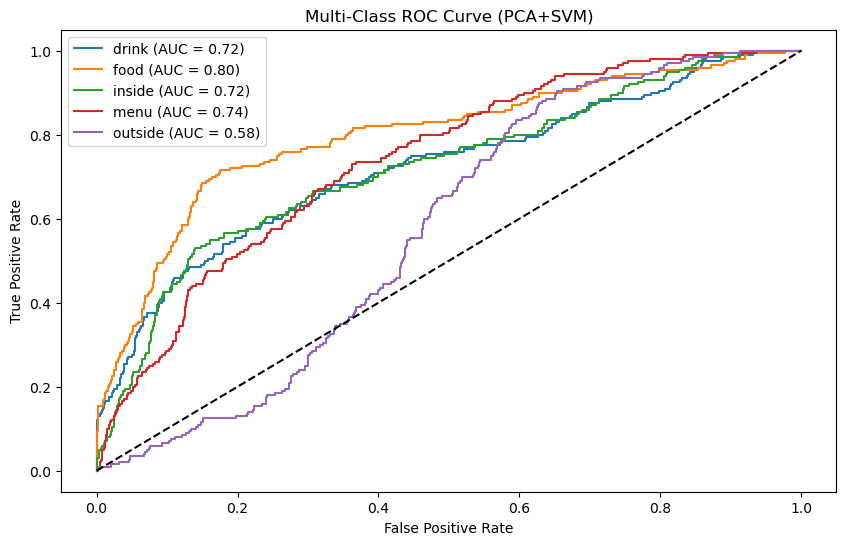

In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Predict using best model
y_test_bin = label_binarize(y_test_enc, classes=list(range(len(le.classes_))))
y_proba = best_model.predict_proba(X_test_pca)

# Plot ROC
plt.figure(figsize=(10, 6))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multi-Class ROC Curve (PCA+SVM)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Model Evaluation

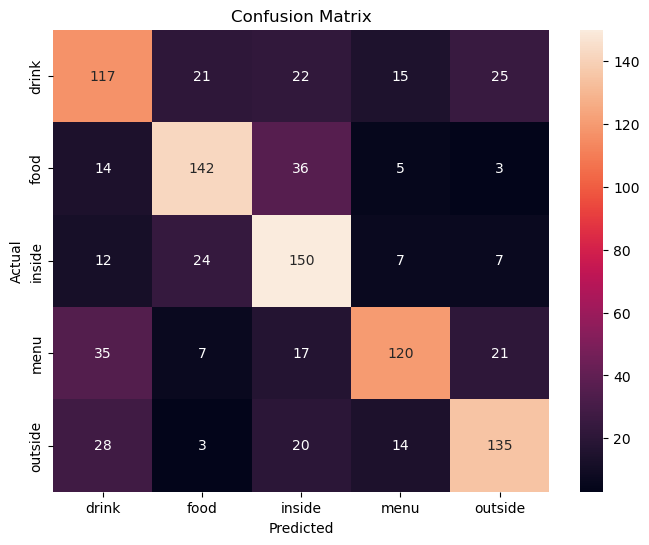

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

       drink       0.57      0.58      0.58       200
        food       0.72      0.71      0.72       200
      inside       0.61      0.75      0.67       200
        menu       0.75      0.60      0.66       200
     outside       0.71      0.68      0.69       200

    accuracy                           0.66      1000
   macro avg       0.67      0.66      0.66      1000
weighted avg       0.67      0.66      0.66      1000



In [51]:
# AUC Score
auc = roc_auc_score(y_test_enc, y_proba, multi_class='ovr')
print(f"AUC Score: {auc:.4f}")

AUC Score: 0.7117


## Model Interpretability

Number of support vectors per class: [769 648 716 647 664]


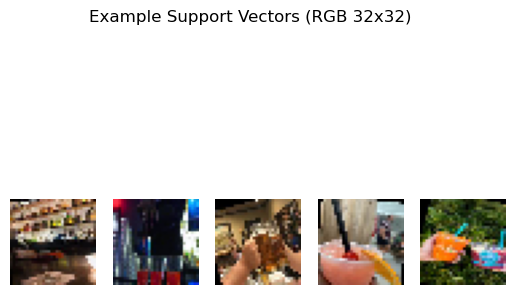

In [53]:
# Visualize support vector counts
if hasattr(clf, 'support_'):
    print("Number of support vectors per class:", clf.n_support_)

# Show first 5 support vectors (RGB, 32x32x3)
support_indices = clf.support_[:5]
for i, idx in enumerate(support_indices):
    img = X_train[idx].reshape(32, 32, 3)  # reshape back to RGB image
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle("Example Support Vectors (RGB 32x32)")
plt.show()

## Analyze Decision Function Values
The decision_function() gives the signed distance from the margin:

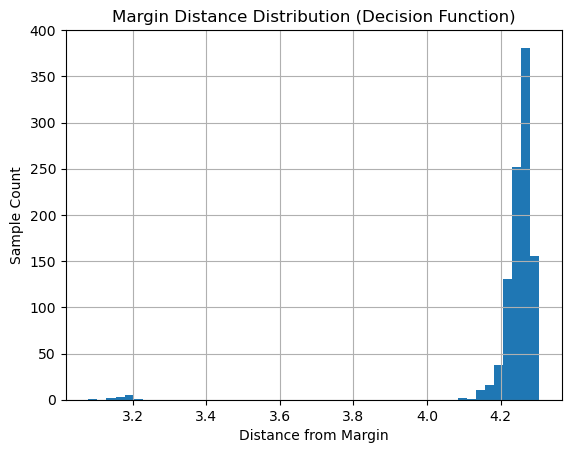

In [55]:
scores = clf.decision_function(X_test_scaled)

# Plot histogram of distances
plt.hist(scores.max(axis=1), bins=50)
plt.title("Margin Distance Distribution (Decision Function)")
plt.xlabel("Distance from Margin")
plt.ylabel("Sample Count")
plt.grid(True)
plt.show()




*   Samples near 0 = close to margin = harder to classify.
*   Large values = confidently classified.




## Visualizing the misclassified sample
### Displays true vs predicted class above each misclassified image

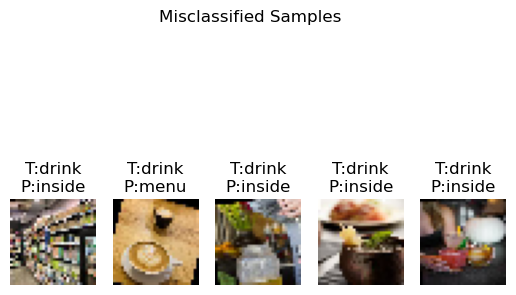

In [58]:
import numpy as np

misclassified = np.where(y_pred != y_test_enc)[0]
for i, idx in enumerate(misclassified[:5]):
    img = X_test[idx].reshape(32, 32, 3)
    true_label = le.inverse_transform([y_test_enc[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis('off')
plt.suptitle("Misclassified Samples")
plt.show()

## Decision Boundary (for 2D PCA projection)

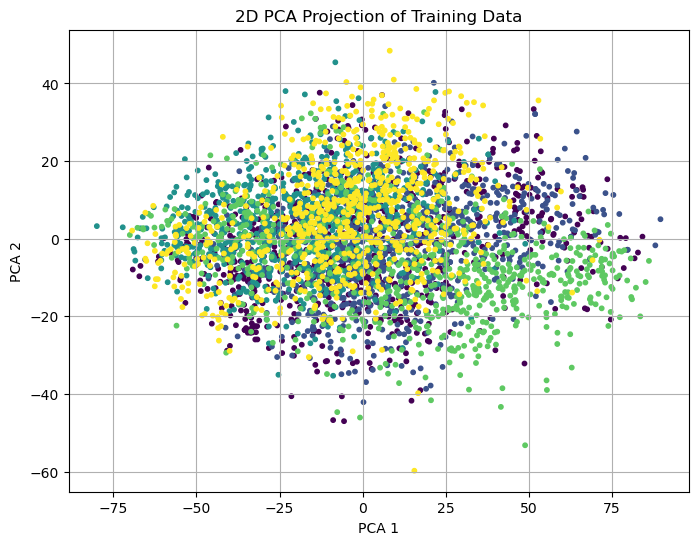

In [60]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_vis = pca_2d.fit_transform(X_train_scaled)

clf_vis = svm.SVC(kernel='rbf', C=1, gamma='scale')
clf_vis.fit(X_vis, y_train_enc)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_train_enc, cmap='viridis', s=10)
plt.title("2D PCA Projection of Training Data")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

## Hence, this shows how distinguishable the classes are, clearly we can see that there is class overlap

## LIME Explainer

  0%|          | 0/1000 [00:00<?, ?it/s]

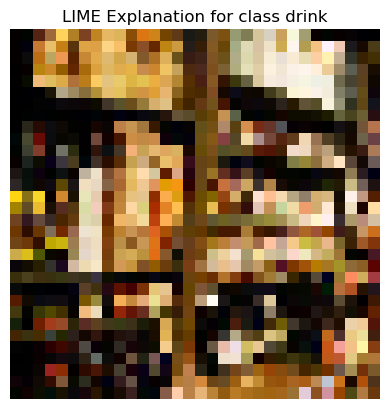

In [75]:
import lime
from lime import lime_image
import numpy as np
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

# Pick one test image 
img = X_test[0].reshape(32, 32, 3)

# Defining a prediction function that takes a batch of images and returns probabilities
def predict_fn(images):
    images_reshaped = images.reshape((images.shape[0], -1))  # flatten
    images_scaled = scaler.transform(images_reshaped)        # scale
    return clf.predict_proba(images_scaled)

# Explain prediction for one image
explanation = explainer.explain_instance(img, 
                                         classifier_fn=predict_fn, 
                                         top_labels=5, 
                                         hide_color=0, 
                                         num_samples=1000)

# Get image and mask for the top predicted label
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)

plt.imshow(temp)
plt.title(f"LIME Explanation for class {le.inverse_transform([explanation.top_labels[0]])[0]}")
plt.axis('off')
plt.show()

## Randomly Uploading Images from Dataset and Predict

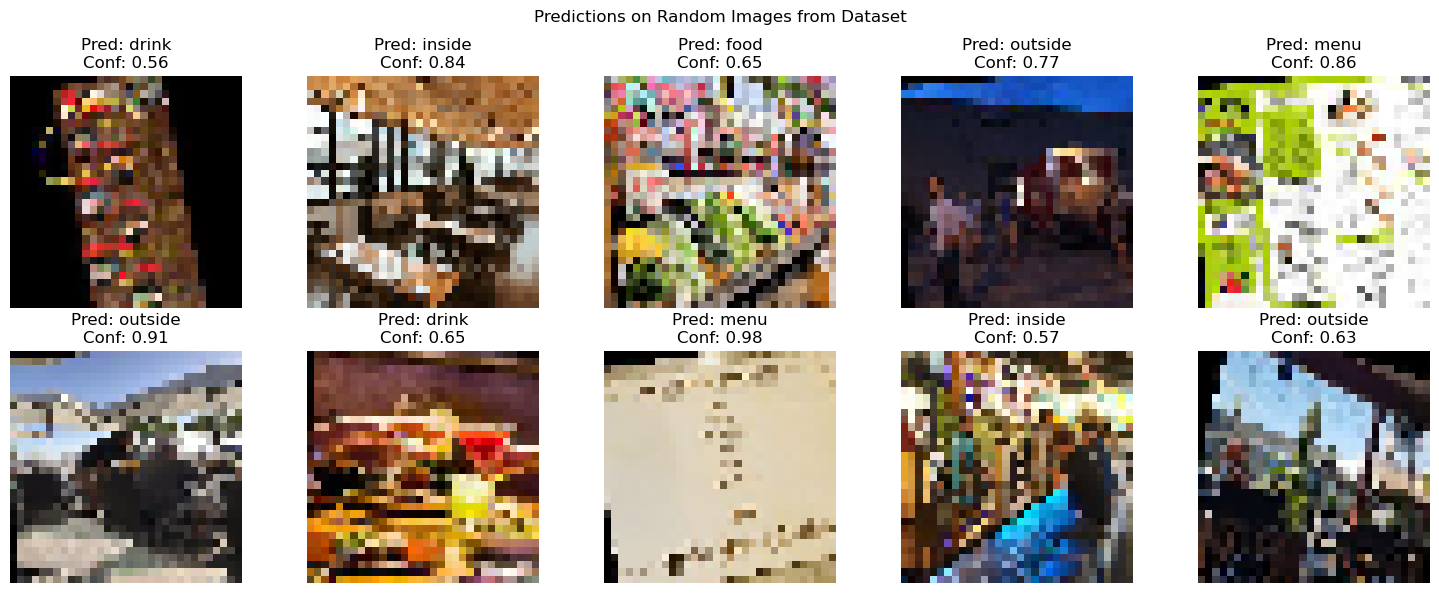

In [77]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Path
dataset_path = "./yelp_photos/balanced_labeled_photos"

# Get list of all image file paths from all classes
all_image_paths = []
all_labels = []
class_names = sorted(os.listdir(dataset_path))
for label in class_names:
    class_folder = os.path.join(dataset_path, label)
    image_files = [os.path.join(class_folder, f) for f in os.listdir(class_folder)]
    all_image_paths.extend(image_files)
    all_labels.extend([label]*len(image_files))

# Randomly select 10 images
random_indices = random.sample(range(len(all_image_paths)), 10)
selected_image_paths = [all_image_paths[i] for i in random_indices]

# Predict and display
plt.figure(figsize=(15,6))

for i, img_path in enumerate(selected_image_paths):
    img = load_img(img_path, target_size=(32, 32))  # Resize as per model input
    img_array = img_to_array(img) / 255.0
    img_flat = img_array.flatten().reshape(1, -1)
    img_scaled = scaler.transform(img_flat)  # Your trained scaler

    pred_encoded = clf.predict(img_scaled)[0]
    pred_label = le.inverse_transform([pred_encoded])[0]
    pred_prob = clf.predict_proba(img_scaled).max()

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"Pred: {pred_label}\nConf: {pred_prob:.2f}")
    plt.axis('off')

plt.suptitle("Predictions on Random Images from Dataset")
plt.tight_layout()
plt.show()

# LLM Used
Kabir:
1. How to Downsample images to decrease processing time.
2. How to implement SVM model on attached sample dataset and how to do Hyperparameter tuning

Aesha:
3. Perform model interpretability and model evaluation of the attached file.
4. Provide code for checking missclassified image visualization and plot graph for decision boundary
5. Perform Lime and check the result when we pick random images from dataset to predict and check accuracy